In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
import torch
import torch.nn as nn

In [4]:
import time

In [5]:
df = pd.read_csv("train.csv")

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.shape

(891, 12)

In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df.drop(["Cabin", "Ticket", "PassengerId"], axis=1, inplace=True)

In [10]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


In [11]:
df["Title"] = df["Name"].str.extract(
    r' ([A-Za-z]+)\.',
    expand=False
)

In [12]:
df["Title"].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [13]:
df["Title"] = df["Title"].replace(
    [
        "Lady", "Countess", "Capt", "Col",
        "Don", "Dr", "Major", "Rev",
        "Sir", "Jonkheer"
    ],
    "Rare"
)

In [14]:
df["Title"] = df["Title"].replace({
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
})

In [15]:
df["Title"].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [16]:
df.drop("Name", axis=1, inplace=True)

In [17]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
Title         0
dtype: int64

In [18]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [19]:
df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

In [20]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Title       0
dtype: int64

In [21]:
df["Sex"] = df["Sex"].map({
    "female": 0,
    "male": 1
})

In [22]:
df["Sex"].value_counts()

Sex
1    577
0    314
Name: count, dtype: int64

In [23]:
df = pd.get_dummies(
    df,
    columns=["Embarked", "Title"],
    drop_first=True
)

In [24]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,1,22.0,1,0,7.2500,False,True,False,True,False,False
1,1,1,0,38.0,1,0,71.2833,False,False,False,False,True,False
2,1,3,0,26.0,0,0,7.9250,False,True,True,False,False,False
3,1,1,0,35.0,1,0,53.1000,False,True,False,False,True,False
4,0,3,1,35.0,0,0,8.0500,False,True,False,True,False,False


In [25]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [26]:
df.groupby("FamilySize")["Survived"].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

In [27]:
df["FamilyCategory"] = pd.cut(
    df["FamilySize"],
    bins=[0, 1, 4, 20],
    labels=[0, 1, 2],
    include_lowest=True
)

In [28]:
df["FamilyCategory"]

0      1
1      1
2      0
3      1
4      0
      ..
886    0
887    0
888    1
889    0
890    0
Name: FamilyCategory, Length: 891, dtype: category
Categories (3, int64): [0 < 1 < 2]

In [29]:
df["FamilyCategory"] = df["FamilyCategory"].astype(int)

In [30]:
df["FamilyCategory"]

0      1
1      1
2      0
3      1
4      0
      ..
886    0
887    0
888    1
889    0
890    0
Name: FamilyCategory, Length: 891, dtype: int64

In [31]:
df[["FamilySize", "FamilyCategory"]].head(10)

,FamilySize,FamilyCategory
0,2,1
1,2,1
2,1,0
3,2,1
4,1,0
5,1,0
6,1,0
7,5,2
8,3,1
9,2,1


In [32]:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [33]:
df.drop(
    ["SibSp", "Parch", "FamilySize"],
    axis=1,
    inplace=True
)

In [34]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,FamilyCategory,IsAlone
0,0,3,1,22.0,7.2500,False,True,False,True,False,False,1,0
1,1,1,0,38.0,71.2833,False,False,False,False,True,False,1,0
2,1,3,0,26.0,7.9250,False,True,True,False,False,False,0,1
3,1,1,0,35.0,53.1000,False,True,False,False,True,False,1,0
4,0,3,1,35.0,8.0500,False,True,False,True,False,False,0,1


In [35]:
bool_columns = df.select_dtypes(include="bool").columns

df[bool_columns] = df[bool_columns].astype(int)

In [36]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,FamilyCategory,IsAlone
0,0,3,1,22.0,7.2500,0,1,0,1,0,0,1,0
1,1,1,0,38.0,71.2833,0,0,0,0,1,0,1,0
2,1,3,0,26.0,7.9250,0,1,1,0,0,0,0,1
3,1,1,0,35.0,53.1000,0,1,0,0,1,0,1,0
4,0,3,1,35.0,8.0500,0,1,0,1,0,0,0,1


In [37]:
X = df.drop("Survived", axis=1).values

y = df["Survived"].values

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [40]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [41]:
y_train = y_train.view(-1, 1)

y_test = y_test.view(-1, 1)

In [42]:
print(X_train.shape)

print(y_train.shape)

torch.Size([712, 12])
torch.Size([712, 1])


In [43]:
class TitanicNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(12, 16),  # Input Layer
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(16, 8), # Hidden Layer
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(8, 1) # Output Layer
            
        )
    
    def forward(self, x):

        return self.model(x)

In [44]:
model = TitanicNN()

In [45]:
print(model)

TitanicNN(
  (model): Sequential(
    (0): Linear(in_features=12, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=16, out_features=8, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [46]:
loss_function = nn.BCEWithLogitsLoss()

In [47]:
optimiser = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=0.001
)

In [48]:
outputs = model(X_train)

print(outputs.shape)

torch.Size([712, 1])


In [49]:
epochs = 300

losses = []

start = time.time()

for epoch in range(epochs):

    outputs = model(X_train)

    loss = loss_function(outputs, y_train)

    optimiser.zero_grad()

    loss.backward()

    optimiser.step()

    losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch + 1} / {epochs}]\tLoss: {loss.item():.4f}")

end = time.time()

print(f"Time taken for training: {end - start} seconds")

Epoch [10 / 300]	Loss: 0.6911
Epoch [20 / 300]	Loss: 0.6777
Epoch [30 / 300]	Loss: 0.6608
Epoch [40 / 300]	Loss: 0.6498
Epoch [50 / 300]	Loss: 0.6448
Epoch [60 / 300]	Loss: 0.6210
Epoch [70 / 300]	Loss: 0.6048
Epoch [80 / 300]	Loss: 0.5906
Epoch [90 / 300]	Loss: 0.5712
Epoch [100 / 300]	Loss: 0.5695
Epoch [110 / 300]	Loss: 0.5426
Epoch [120 / 300]	Loss: 0.5370
Epoch [130 / 300]	Loss: 0.5419
Epoch [140 / 300]	Loss: 0.5229
Epoch [150 / 300]	Loss: 0.5230
Epoch [160 / 300]	Loss: 0.5034
Epoch [170 / 300]	Loss: 0.4960
Epoch [180 / 300]	Loss: 0.4968
Epoch [190 / 300]	Loss: 0.5070
Epoch [200 / 300]	Loss: 0.4889
Epoch [210 / 300]	Loss: 0.4981
Epoch [220 / 300]	Loss: 0.4608
Epoch [230 / 300]	Loss: 0.4680
Epoch [240 / 300]	Loss: 0.4699
Epoch [250 / 300]	Loss: 0.4610
Epoch [260 / 300]	Loss: 0.4605
Epoch [270 / 300]	Loss: 0.4641
Epoch [280 / 300]	Loss: 0.4773
Epoch [290 / 300]	Loss: 0.4547
Epoch [300 / 300]	Loss: 0.4536
Time taken for training: 0.27779102325439453 seconds


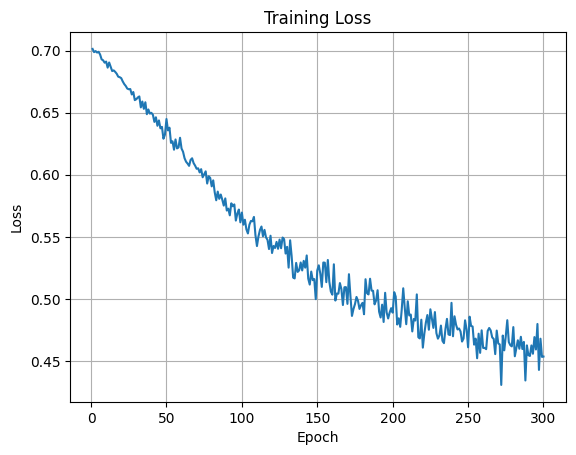

In [50]:
plt.plot(range(1, epochs + 1), losses)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

In [51]:
model.eval()

TitanicNN(
  (model): Sequential(
    (0): Linear(in_features=12, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=16, out_features=8, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)

In [52]:
with torch.no_grad():

    outputs = model(X_test)

In [53]:
outputs[0]

tensor([-0.3481])

In [54]:
probabilities = torch.sigmoid(outputs)

In [55]:
probabilities[:10]

tensor([[0.4139],
        [0.1659],
        [0.1190],
        [0.7258],
        [0.6346],
        [0.8339],
        [0.6757],
        [0.1198],
        [0.6987],
        [0.7806]])

In [56]:
predictions = (probabilities >= 0.5).float()

In [57]:
predictions[:10]

tensor([[0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.]])

In [58]:
correct = (predictions == y_test).sum()

accuracy = (correct / len(y_test) * 100)

print(f"Accuracy: {accuracy} %")

Accuracy: 79.3296127319336 %


In [59]:
torch.save(model.state_dict(), "titanic_nn_model.pth")